In [1]:
using LinearAlgebra
using Plots
using Statistics


# Projeto 2 - Jacobi e Gauss-Seidel

Modelo de entrega.

Respeite as divisões em Markdown para facilitar a navegação no relatório.

## Questão 1a: Implementação

Implemente os métodos de Jacobi e Gauss-Seidel para resolver o sistema linear $Ax = b$.

In [2]:
#Função que retorna o módulo da diferença entre as normas dos nossos vetores, para conseguimos dimensionar o erro da nossa solução
get_erro(x_real, x_aprox) = abs(norm(x_real) - norm(x_aprox))

get_erro (generic function with 1 method)

In [3]:
@time get_erro([1,1,2], [1,1,1])

  0.000007 seconds (4 allocations: 160 bytes)


0.7174389352143007

### JacobiMethod(A, b, n)

Retorna uma aproximação da solução do sistema linear $Ax = b$, utilizando o método iterativo de Jacobi.

O método de Jacobi decompõe a matriz em $A = D + R$ e utiliza a iteração: $x^{(k+1)} = D^{-1}(b - Rx^{(k)})$

#### Argumentos
- `A::Matrix`: Matriz de coeficientes.
- `b::Vector`: Vetor resultante.
- `n::Int`: Número máximo de iterações.

#### Retorno
- `x::Vector`: Aproximação da solução x após as n iterações.


In [4]:
function JacobiMethod(A::Matrix , b:: Vector, ϵ:: Float64, verbose:: Bool = false, iteracoes:: Bool = false)
    m = size(A,1)
    x = ones(m) #Chute inicial

    hist_erros = Float64[]
    erro = 1
    it = 0

    while erro >= ϵ
        xᵏ = copy(x)

        for i in 1:m
            diag_inv = 1/A[i,i]
            d = diag_inv * b[i] #Cálculo do D⁻¹[i,i]*b[i]

            soma = 0
            for j in 1:m #Cálculo do D⁻¹Rx
                if j != i
                    soma = soma + diag_inv * A[i,j] * xᵏ[j] #∑D⁻¹[i,i] * A[i,j] * xᵏ[j]
                end
            end

            x[i] = d - soma # x =  D⁻¹b - D⁻¹Rx 
        end

        erro = get_erro(x, xᵏ)
        it+=1
        push!(hist_erros, erro)
    end

    if verbose
        println("Solução Aproximada Gauss Jacobi: ", x)
        println("Histórico de erros: ", hist_erros)
    end

    if iteracoes
        return x, hist_erros, it
    end
    
        
    return x, hist_erros
end

JacobiMethod (generic function with 3 methods)

In [5]:
function GaussSeidelMethod(A::Matrix , b:: Vector, ϵ:: Float64, verbose:: Bool = false, iteracoes:: Bool = false)
    m = size(A,1)
    x = ones(m) #Chute inicial

    hist_erros = Float64[]
    erro = 1
    it = 0

    while erro >= ϵ
        xᵏ = copy(x)

        for i in 1:m
            diag_inv = 1/A[i,i]
            d = diag_inv * b[i] #Cálculo do D⁻¹[i,i]*b[i]

            
            soma = 0
            for j in 1:m #Cálculo do D⁻¹Rx
                if j != i
                    soma = soma + diag_inv * A[i,j] * x[j]
                end
            end

            x[i] = d - soma
            
        end

        erro = get_erro(x, xᵏ)
        push!(hist_erros, erro)
    end

    if verbose
        println("Solução Aproximada Gauss Seidel: ", x)
        println("Histórico de erros: ", hist_erros)
    end

    if iteracoes
        return x, hist_erros, it
    end
    
    return x, hist_erros
end

GaussSeidelMethod (generic function with 3 methods)

Qual deveria ser a complexidade computacional do código que você escreveu?

Para melhor compreensão da complexidade das nossas funções, escolhi não utilizar algumas facilidades do Julia. Dessa forma, podemos perceber que em ambos possuímos 3 for's aninhados, o primeiro que vai até n e os dois últimos até m, o que configura uma complexidade $O(n*m^2)$.

## Questão 1b: Testes
Teste com matrizes $2 \times 2$ e $3 \times 3$, e compare graficamente a velocidade de convergência dos dois métodos.

In [6]:
function plotar_comparativo(A, b)
    x_j, arr1 = JacobiMethod(A, b, 10^(-12))
    x_gs, arr2 = GaussSeidelMethod(A, b, 10^(-12))

    println("Solução Real :", A\b)
    println("Solução Aproximada Jacobi :", x_j)
    println("Solução Aproximada Gauss Seidel: ", x_gs)
    
    eixo_1 = 1:length(arr1)
    eixo_2 = 1:length(arr2)

    plot(eixo_1, arr1, label= "Jacobi", marker= :o, yscale= :log10)
    plot!(eixo_2, arr2, label= "Gauss-Seidel", marker= :o, yscale= :log10)

    title!("Convergência")
    xlabel!("Iterações")
    ylabel!("Erro")

end

plotar_comparativo (generic function with 1 method)

Solução Real :[0.9770114942528736, 2.1494252873563218]
Solução Aproximada Jacobi :[0.9770114942532573, 2.149425287356318]
Solução Aproximada Gauss Seidel: [0.9770114942532573, 2.149425287356212]


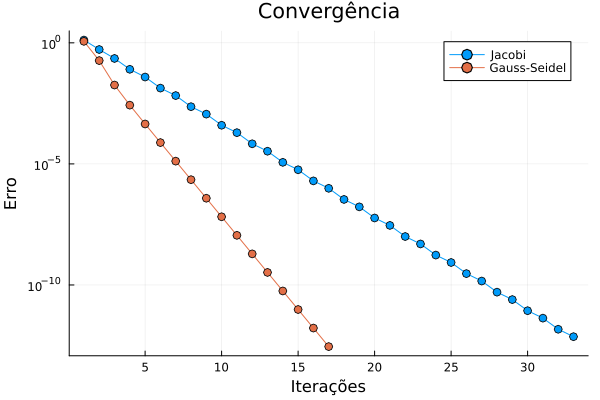

In [7]:
A = [15 9; 2 7]
b = [34, 17]

plotar_comparativo(A,b)


Solução Real :[0.3191489361702128, 0.40425531914893614]
Solução Aproximada Jacobi :[0.31914893617014073, 0.40425531914881263]
Solução Aproximada Gauss Seidel: [0.31914893617014073, 0.40425531914895774]


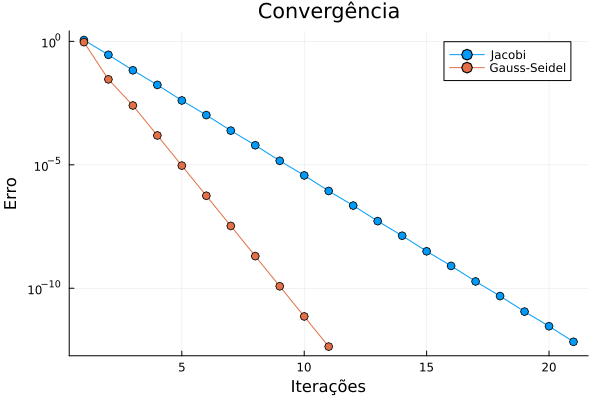

In [8]:
A = [10 2; 3 10]
b = [4, 5]

plotar_comparativo(A,b)

Solução Real :[3.7878281622911696, 1.7305489260143199, -1.2990453460620526]
Solução Aproximada Jacobi :[3.7878281622906815, 1.730548926013955, -1.2990453460624358]
Solução Aproximada Gauss Seidel: [3.787828162291648, 1.7305489260145164, -1.299045346062362]


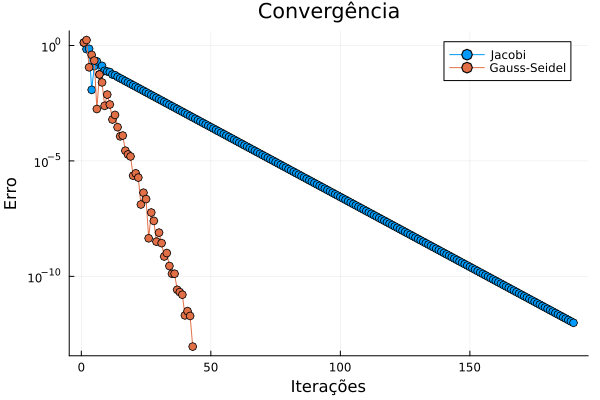

In [9]:
A = [15 9 8; 1 10 7; 21 4 35]
b = [62, 12, 41]

plotar_comparativo(A,b)


Solução Real :[2.8739649842320296, 0.19794628015721372, -0.6984511658976869]
Solução Aproximada Jacobi :[2.873964984232412, 0.19794628015744797, -0.6984511658973622]
Solução Aproximada Gauss Seidel: [2.873964984232148, 0.19794628015720284, -0.6984511658977108]


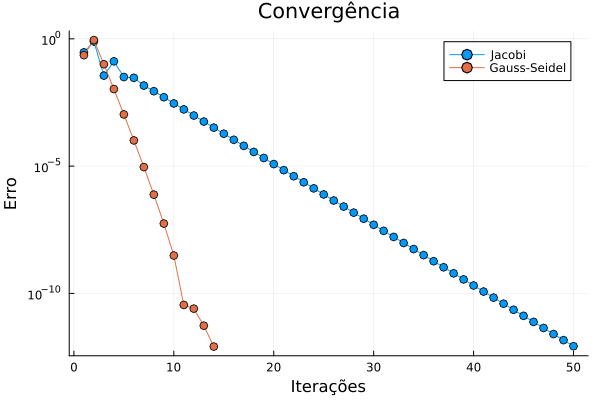

In [10]:
A = [42 16 17; 9 35 4; 13 22 54]
b = [112, 30, 4]

plotar_comparativo(A,b)

In [11]:
function plotar_comparativo_mod(A, b)
    x_j, arr1 = JacobiMethod(A, b, 10^(-12))
    x_gs, arr2 = GaussSeidelMethod(A, b, 10^(-12))

    println("Solução Real :", A\b)
    println("Solução Aproximada Jacobi :", x_j)
    println("Solução Aproximada Gauss Seidel: ", x_gs)
    
    eixo_1 = 1:length(arr1)
    eixo_2 = 1:length(arr2)

    plot(eixo_1, arr1, label= "Jacobi", marker= :o)
    plot!(eixo_2, arr2, label= "Gauss-Seidel", marker= :o)

    title!("Convergência")
    xlabel!("Iterações")
    ylabel!("Erro")

end

plotar_comparativo_mod (generic function with 1 method)

In [12]:
# Código gerando gráficos

(Comentários)

## Questão 1c: Matrizes maiores
Teste com matrizes maiores.  Estes métodos funcionam para matrizes do tipo `rand(m,m)`?

In [13]:
A= rand(5,5)
b= rand(5)


println("Solução Real: ", A\b)
JacobiMethod(A, b, 0.9, true) 
GaussSeidelMethod(A, b, 0.9, true)

Solução Real: [0.7690604922820192, 1.9205276796682784, -2.531842763646569, -0.2187765196379189, 0.42980684597994123]
Solução Aproximada Gauss Jacobi: [Inf, Inf, Inf, Inf, Inf]
Histórico de erros: [16.950892139825726, 101.04421482148116, 670.6005328779397, 4619.934429039492, 30295.185724840718, 204903.81680129122, 1.3647964135818644e6, 9.149273236745125e6, 6.1193038387150876e7, 4.095440776048563e8, 2.7406767540994434e9, 1.8339868116371433e10, 1.2273177483098444e11, 8.213031637753455e11, 5.496133022966698e12, 3.677967079693861e13, 2.4612719473475972e14, 1.6470660577746758e15, 1.1022053060917932e16, 7.375882504623722e16, 4.935889866309924e17, 3.3030636795333304e18, 2.2103875431298793e19, 1.4791761842980225e20, 9.898545548179952e20, 6.624038779458053e21, 4.432761311147172e22, 2.9663734612057555e23, 1.985076771363894e24, 1.328399758022527e25, 8.889560054323856e25, 5.948832607164001e26, 3.9809179725343524e27, 2.6640029986629277e28, 1.7827325320066757e29, 1.1929923811159441e30, 7.983423176771

([1.8134793013338106e307, -2.065434063783647e306, 3.435789445379934e307, -3.140953683385447e307, NaN], [7.864735505635458, 49.09637624103992, 18.629443296989628, 488.128894189153, 760.6239557263707, 2585.320616601065, 14941.807398269088, 4877.308771521886, 163627.89489336178, 243178.11555581007  …  3.609533329754511e302, 1.1074799322484394e304, 1.3375245880804318e304, 6.645472714690214e304, 3.0274775128481768e305, 1.2170595097529568e305, 3.636088820389566e306, 4.275790053782491e306, 2.215715937283894e307, NaN])

In [14]:
A= rand(30,30)
b= rand(30)


println("Solução Real: ", A\b)
JacobiMethod(A, b, 0.9, true) 
GaussSeidelMethod(A, b, 0.9, true)

Solução Real: [1.7468686222209484, -0.9584143024064923, -0.6723882292851482, -0.6710808283250486, -0.3339778460258859, 1.2114974214886367, -0.20961193335531228, -1.16808818946657, 0.913290977878915, 0.31941904444060853, 0.14343890461921902, -2.6455434586000295, 1.1815875734906518, -1.262100972498937, -1.3205297300908097, 1.8378227789756876, 1.9588001429924353, 0.8166301059343974, 0.2520758987013418, 1.5796374092234073, 0.13777449341999315, 3.512075246823436, -1.7641695629530745, -1.2722224465828154, -0.618732846001309, -1.070232447313944, -0.9145119094823146, 0.2743527761540611, 0.3290425441977159, 0.7907059111862549]
Solução Aproximada Gauss Jacobi: [-Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf, -Inf]
Histórico de erros: [892.874774894692, 60153.62112829432, 4.644588478915375e6, 3.490360433589057e8, 2.637389745964859e10, 1.9907630753713677e12, 1.5029695864422

([-1.0058933860848887e305, 1.0558036681798923e305, -1.2894747250720742e306, 2.6686600794655378e306, -6.700099609764082e305, -1.1357167410159858e306, 2.3819224702876063e306, -2.70579952526674e306, 6.859783686036277e307, -5.4862719319319113e306  …  NaN, NaN, NaN, NaN, NaN, NaN, NaN, NaN, NaN, NaN], [2.156944195772977e9, 1.2222169751947523e17, 6.925606688166349e24, 3.924346410876706e32, 2.2237033441236837e40, 1.2600458891604765e48, 7.139961573498018e55, 4.045809101841034e63, 2.292529325269247e71, 1.2990456482061577e79  …  8.572829328772154e241, 4.857733556384349e249, 2.7526006175842413e257, 1.5597418162153468e265, 8.838167504975113e272, 5.008085571209248e280, 2.8377965312872734e288, 1.6080174826249237e296, 9.111718179648577e303, NaN])

In [15]:
A= rand(50, 50)
b= rand(50)


println("Solução Real: ", A\b)
JacobiMethod(A, b, 0.9, true) 
GaussSeidelMethod(A, b, 0.9, true)

Solução Real: [1.040402604513952, -0.5329163158502918, 1.3185023491190797, -0.006343892189620003, 0.5650899005962802, 1.7125544674791267, 0.6767621922578687, 1.1756921687312514, -0.038122018495136606, 0.4339865269162291, -0.4825145410702045, -0.25299639750991415, -0.31085738366739585, -1.508942749485084, 0.13345125745547673, -1.2119836759728542, -0.14204570444717204, -0.02165758589266855, -0.9948572846549728, -0.4817495461496788, 1.5623394547119833, 0.2930825462108713, -0.3192354711335808, 0.500047516756201, -0.4486523190734792, -0.015107133574774723, -0.4671832069240163, 0.31662912168180785, -0.49048042953865184, -0.9560886535464228, -0.7349602334854571, 0.5124504402395383, -0.3515505752838192, 0.5831403004243546, 1.6994580505319221, -2.038330689709053, 0.09096313684799491, 0.23605128220257884, -0.4278780118703675, -0.7484772521343515, -0.06072751858640317, 0.5655933181167289, 1.070412107261026, 1.3327879540242713, -0.2960423442138364, -1.0293121963591594, -0.9462420324774967, 0.04640

([3.870583078813547e307, -1.0134048471894207e307, -7.681564657022574e307, -2.8640314479180495e307, 1.900121201478227e307, NaN, NaN, NaN, NaN, NaN  …  NaN, NaN, NaN, NaN, NaN, NaN, NaN, NaN, NaN, NaN], [5.310000158535402e10, 1.0182874700812065e20, 1.952746559079181e29, 3.744737351714223e38, 7.181197051980219e47, 1.3771217112399755e57, 2.640874764807578e66, 5.06434505133018e75, 9.711778513965505e84, 1.862405522300474e94  …  3.248676531459528e233, 6.229912578481522e242, 1.1946960665267016e252, 2.2910412841174354e261, 4.393477397803945e270, 8.425270979981576e279, 1.6156949190543777e289, 3.098381141283846e298, 5.941694551024533e307, NaN])

Em geral, os métodos não funcionam para matrizes `rand(m,m)`.

## Questão 1d: Matrizes maiores ainda!
Quão grande deve ser $k(m)$ para funcionar para 95\% das matrizes do tipo `randn(m,m)` + $ k(m) \cdot I_m$?  Quais velocidades de convergência você observa para este $k(m)$?

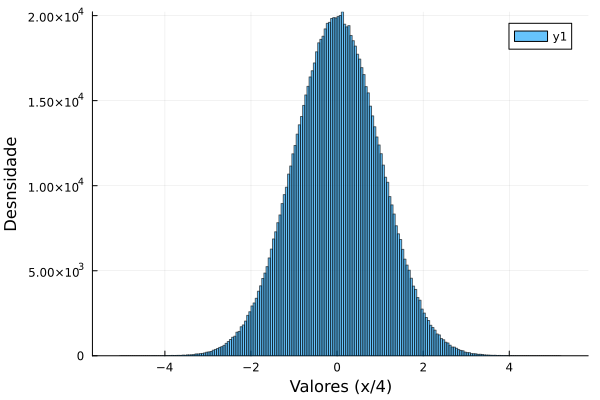

In [16]:
dist = randn(1000000)

histogram(dist, bins= :auto, xlabel= "Valores (x/4)", ylabel= "Desnsidade", alpha= 0.6)

In [17]:
row_sums = sum(abs.(A), dims= 2)
max_norm, row_idx = findmax(row_sums)
A[row_idx[1],:]

50-element Vector{Float64}:
 0.8552576833862534
 0.35683197075184714
 0.7510447000923564
 0.8176206893500598
 0.08291036194555257
 0.6380323212318281
 0.7928612769669736
 0.6639972421044594
 0.5236891112695032
 0.2966225767514423
 ⋮
 0.4002589181345908
 0.8592572384620785
 0.04685486349210333
 0.7790643434655125
 0.8412164985666538
 0.39126256853027774
 0.8448681553996877
 0.5905739258349839
 0.12775929343187475

In [18]:
M = rand(3, 3)

# Zerar a diagonal principal
M[diagind(M)] .= 0

3-element view(::Vector{Float64}, 1:4:9) with eltype Float64:
 0.0
 0.0
 0.0

In [19]:
A = randn(5,5)
D = Diagonal(diag(A))
A[diagind(A)] .= 0
M = inv(D)*(A)

5×5 Matrix{Float64}:
 0.0        2.99472     -2.27566   -0.503096    3.61245
 3.57004   -0.0        -10.7455    -5.08444     0.260825
 0.161052   1.22785      0.0       -0.0899541  -0.274035
 0.512049   0.0226574    0.842514   0.0        -0.582184
 1.5665     1.01559      0.753186   0.307503    0.0

In [20]:
# data = Float64[]
# f(m) = 4*m

# for i in 1:100000
#     A = randn(2, 2) + 3.648929468919049*Matrix(I,2,2)
#     D = Diagonal(diag(A))
#     A[diagind(A)] .= 0
#     M = inv(D)*(A) 

#     row_sums = sum(abs.(M), dims= 2)
#     max_norm, row_idx = findmax(row_sums)
#     k = max_norm
#     push!(data, k)
# end

# histogram(data, bins= :auto, alpha= 0.6)






In [21]:
# resultado = count(x -> x < 1, data)
# resultado/length(data)

In [ ]:
data_k_min = Float64[]

for dim in 2:200
    data = Float64[]
    println(dim)
    for i in 1:1000
    A = randn(dim,dim)
    diagonal = diag(A)
    A[diagind(A)] .= 0

    row_sums = sum(abs.(A), dims= 2)
    max_norm, row_idx = findmax(row_sums)
    k_min = max_norm - diagonal[row_idx[1]]
    push!(data, k_min)
    end
    k95 = quantile(data, 0.95)
    push!(data_k_min, k95)
end

In [48]:
data_k_min

49-element Vector{Float64}:
  3.0796535015737376
  4.460471718912048
  5.766144653376322
  7.016017459990616
  8.233157887763289
  9.419013371946557
 10.5814193739576
 11.723312124348649
 12.854431588731561
 13.967445786808536
  ⋮
 45.50581376495989
 46.481558449386114
 47.44517712842617
 48.41499878917746
 49.3786500152494
 50.33848226102301
 51.29436072722292
 52.271380295786436
 53.221076128159766

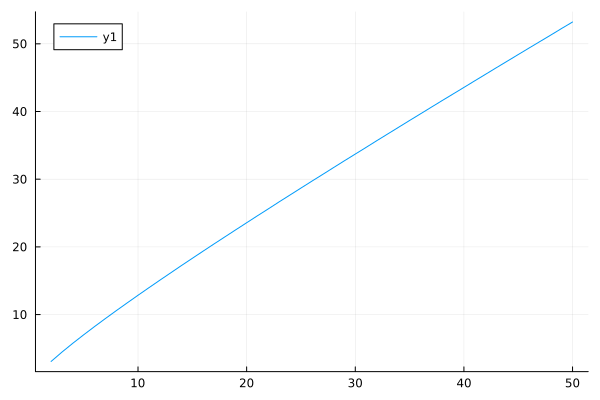

In [ ]:
plot(2:200, data_k_min)

In [38]:
function createPhi(vetor, n)
    Phi = zeros(size(vetor, 1), n+1)
    for i in 1:n+1
        Phi[:,i] .+= vetor.^(i-1)
    end 
    return Phi

end

createPhi (generic function with 1 method)

In [45]:
Phi1 = createPhi([2:50;], 1)

49×2 Matrix{Float64}:
 1.0   2.0
 1.0   3.0
 1.0   4.0
 1.0   5.0
 1.0   6.0
 1.0   7.0
 1.0   8.0
 1.0   9.0
 1.0  10.0
 1.0  11.0
 ⋮    
 1.0  42.0
 1.0  43.0
 1.0  44.0
 1.0  45.0
 1.0  46.0
 1.0  47.0
 1.0  48.0
 1.0  49.0
 1.0  50.0

In [40]:
function linear_regression_PI(Phi, target)
    PhiTPhi = transpose(Phi)*Phi
    pinv = inv(PhiTPhi)*transpose(Phi)
    w_learned = pinv*target
    return w_learned


end

linear_regression_PI (generic function with 1 method)

In [50]:
w_learned = linear_regression_PI(Phi1, data_k_min)

2-element Vector{Float64}:
 2.529337842156106
 1.0279233133302859

In [ ]:
f(m) =   1.7992749418770098 + m * 1.0795403015420795 

function test(dim)
data = Float64[]

for i in 1:1000
    A = randn(dim,dim) + f(dim)*Matrix(I,dim, dim)
    D = Diagonal(1 ./ diag(A))
    A[diagind(A)] .= 0
    M = D*A

    row_sums = sum(abs.(M), dims= 2)
    max_norm, row_idx = findmax(row_sums)
    k = max_norm
    push!(data, k)
end
    resultado = count(x -> x < 1, data)
    # resultado/length(data)
    println(resultado/length(data))

end

test (generic function with 1 method)

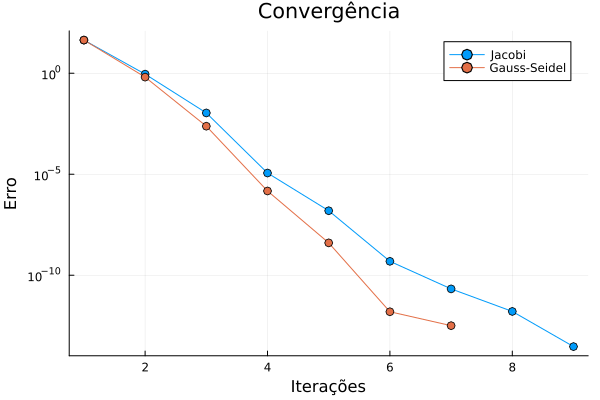

In [65]:
dim =2000

A = randn(dim,dim) + f(dim)*Matrix(I,dim, dim) 
b = rand(dim)

plotar_comparativo(A,b)

In [66]:
test(50)

Solução Real :[0.030710921907402884, -0.04864200675194902, -0.08791655471174059, -0.07670320652379109]
Solução Aproximada Jacobi :[0.03071092190547913, -0.04864200675111317, -0.08791655471008983, -0.0767032065252822]
Solução Aproximada Gauss Seidel: [0.030710921905624883, -0.04864200675251921, -0.08791655471229623, -0.07670320652343207]


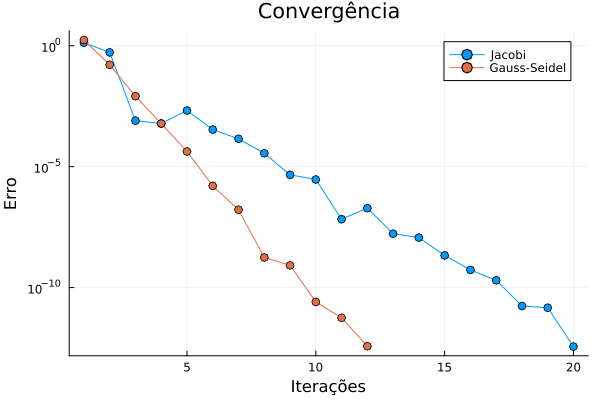

In [32]:
dim = 4
A = randn(dim,dim) + f(dim)*Matrix(I,dim, dim)
b = randn(dim)

plotar_comparativo(A,b)

In [33]:
# Código (gerando possivelmente gráficos ou tabelas)

(Comentários)

## Questão 1e: Jacobi vs Gauss-Seidel
Encontre uma matriz $A$ $4 \times 4$ para a qual o método de Jacobi tenha melhor convergência que o método de Gauss-Seidel.

(Explique suas ideias, verifique abaixo)

In [34]:
# Código
it_j = 1
it_gs = 0

for it_j > it_gs
    A = randn(4,4) + f(4)*Matrix(I,4, 4)
    b = rand(4)

    x_j, hist_j, it_j = JacobiMethod(A,b,10^(-12),false,true)
    x_gs, hist_gs, it_gs =GaussSeidelMethod(A,b,10^(-12),false,true)

    if it_j < it_gs
        println(A)
    end
end

Base.Meta.ParseError: ParseError:
# Error @ c:\Users\sodre\github_repos\fgv_aln\Trab_2\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X63sZmlsZQ==.jl:5:9

for it_j > it_gs
#       └──────┘ ── invalid iteration spec: expected one of `=` `in` or `∈`

## Questão 1f: Perturbações
O que acontece se você somar uma matriz aleatória e pequena à matriz $A$ acima?  O que acontece se esta perturbação acontecer apenas fora da diagonal?

In [ ]:
test(1000)

In [ ]:
# Código

(Comentários)